# 273. H/P agreement between aligned homologs, measured as positions out of 100

No kmerseek in this notebook. It re-reads the aligned pairs of
[notebook 230](https://github.com/seanome/2024-kmerseek-analysis/blob/main/notebooks/230_hp_class_conservation_in_aligned_homologs.ipynb)
and counts, for each pair, how many aligned positions put the two residues in the same
class. Notebook 230 reported this as Cohen's kappa. The numbers "74 of 100 positions agree
in H/P at 20-30% identity, against 51 by chance" were then converted back from kappa using
Swiss-Prot residue shares. Here they are counted directly.

**Data.** The same files notebook 230 reads, with the same filters:

* Pfam-A 38.2 seed alignments: 163,448 sampled pairs from 29,151 families, up to 6 pairs
  per family (`~/data/pfam/230_pfam_seed_pair_alignments.parquet`, built by
  `scripts/pfam_seed_pair_alignments.py`). Pairs with at least 50 aligned positions.
* SCOPe 2.08, 40% identity set: 38,267 domain pairs aligned by structure with USalign
  (`~/data/scope/230_scope40_pair_alignments.parquet`, built by
  `scripts/scope_pair_structural_alignments.py`). Pairs with at least 50 aligned positions
  and TM-score at least 0.5 on one of the two domains.

**Alphabets.** `hp_thomas_dill2`: hydrophobic `ACFILMVWY`, polar `DEGHKNPQRST`.
`protein20`: the 20 amino acids, so "same class" means identical residue.

**Per pair** (an aligned position is a column where neither sequence has a gap):

$$\Pr(\text{agree}) = \frac{\text{aligned positions where both residues are in the same class}}{\text{aligned positions}}$$

$$\Pr(\text{agree by chance}) = h_\text{query}\,h_\text{target} + p_\text{query}\,p_\text{target}$$

where $h_\text{query}$ is the share of the query's aligned residues that are hydrophobic and
$p_\text{query} = 1 - h_\text{query}$ the share that are polar (for protein20, the sum runs
over all 20 amino acids). The shares are the pair's own, not Swiss-Prot's.

**Shuffled null.** The target's residues are shuffled among its own residue positions
(composition and gap pattern kept), and the same aligned columns are scored again. Ten
shuffles per pair, averaged. This measures chance instead of computing it from shares.

**Evidence per aligned position**, in bits: how far the pair's agree/disagree rate is from
the chance rate (the Kullback-Leibler divergence of the two coin flips),

$$I = \Pr(\text{agree})\,\log_2\frac{\Pr(\text{agree})}{\Pr(\text{chance})} + \bigl(1-\Pr(\text{agree})\bigr)\,\log_2\frac{1-\Pr(\text{agree})}{1-\Pr(\text{chance})}$$

computed per pair and averaged over pairs. Zero means the alignment looks like chance;
higher is more evidence of relatedness from each aligned position. The same quantity is
computed for each shuffled pair, against that shuffle's own chance rate. It is above zero
because a finite alignment never lands on its chance rate exactly, so the shuffled value is
the floor to compare against.

**The estimates under test** (from kappa, with Swiss-Prot shares): at 20-30% identity,
H/P 74 agreeing per 100 against 51 by chance; 20 amino acids 25 against 6; I about 0.15 bits
for H/P against 0.26 for 20 amino acids.

**Decision rule, written before running.** If a measured value at 20-30% identity in Pfam is
within 3 positions per 100 (or 0.03 bits for I) of the estimate, the estimate can be quoted.
Otherwise the measured value replaces it in the paper and the SAB material, and this
notebook is the source.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

sys.path.insert(0, str(Path.cwd()))
import hp_conservation_utils as hc

pl.Config.set_tbl_rows(80)
pl.Config.set_tbl_cols(20)
pl.Config.set_tbl_width_chars(220)

FIG = Path("../figures")
PFAM_ALN = Path("/Users/olga/data/pfam/230_pfam_seed_pair_alignments.parquet")
SCOPE_ALN = Path("/Users/olga/data/scope/230_scope40_pair_alignments.parquet")
PFAM_OUT = Path("/Users/olga/data/pfam/273_pfam_seed_pair_agreement_shuffled.parquet")
SCOPE_OUT = Path("/Users/olga/data/scope/273_scope40_pair_agreement_shuffled.parquet")
PFAM_230 = Path("/Users/olga/data/pfam/230_pfam_seed_pair_class_agreement.parquet")
MIN_COLS = 50  # same filter as notebook 230
MIN_TM = 0.5  # SCOPe only, same as notebook 230
N_SHUFFLE = 10
SEED = 273
HP = "hp_thomas_dill2"
P20 = "protein20"
ALPHABETS = [HP, P20]


def load_or_compute(aln_path, out_path, keys):
    # Per-pair agreement, chance, shuffled agreement and evidence; cached to out_path.
    if out_path.exists():
        return pl.read_parquet(out_path)
    aln = pl.read_parquet(aln_path)
    t = hc.compute_pair_table(aln, keys, ALPHABETS, n_shuffle=N_SHUFFLE, seed=SEED)
    t.write_parquet(out_path)
    return t


pfam_raw = load_or_compute(
    PFAM_ALN, PFAM_OUT, ["family", "family_id", "query", "target", "seqid_ali"]
)
scope_raw = load_or_compute(
    SCOPE_ALN, SCOPE_OUT, ["query", "target", "category", "seqid_ali", "tm_q", "tm_t"]
)

pfam = hc.add_identity_bin(pfam_raw).filter(pl.col("n_cols") >= MIN_COLS)
scope = (
    hc.add_identity_bin(scope_raw)
    .filter(pl.col("n_cols") >= MIN_COLS)
    .filter(pl.max_horizontal("tm_q", "tm_t") >= MIN_TM)
)

CAT_ORDER = [
    "same_family",
    "same_superfamily_diff_family",
    "same_fold_diff_superfamily",
    "diff_fold_same_class",
]
CAT_LABEL = {
    "same_family": "same family",
    "same_superfamily_diff_family": "same superfamily,\ndifferent family",
    "same_fold_diff_superfamily": "same fold,\ndifferent superfamily",
    "diff_fold_same_class": "different fold,\nsame class",
}
COLOR = {HP: "#a50f15", P20: "#444444"}  # notebook 230's colours for these two alphabets

# Check against notebook 230: agreement and chance must be identical for the same pairs.
old = pl.read_parquet(PFAM_230).filter(pl.col("alphabet").is_in(ALPHABETS))
chk = pfam_raw.join(
    old.select("family", "query", "target", "alphabet", "agree", "expected"),
    on=["family", "query", "target", "alphabet"],
    suffix="_230",
)
print(
    f"Pfam pairs x alphabets: {pfam_raw.height:_} computed here, {chk.height:_} matched to nb 230; "
    f"max |agree - agree_230| = {(chk['agree'] - chk['agree_230']).abs().max():.2e}, "
    f"max |chance - chance_230| = {(chk['expected'] - chk['expected_230']).abs().max():.2e}"
)
print(
    f"After filters: Pfam {pfam.filter(pl.col('alphabet') == HP).height:_} pairs, "
    f"SCOPe {scope.filter(pl.col('alphabet') == HP).height:_} pairs"
)

Pfam pairs x alphabets: 326_896 computed here, 326_896 matched to nb 230; max |agree - agree_230| = 0.00e+00, max |chance - chance_230| = 0.00e+00
After filters: Pfam 148_482 pairs, SCOPe 24_505 pairs


## 1. One pair, position by position

A Bcl-2 family pair from the Pfam seed (PF00452): rat BCL2L10 (`B2L10_RAT`, residues
39-145) against an opossum Bcl-2 family protein (`F6ZMX1_MONDO`, residues 218-317), 28%
identical over aligned positions, to show what is counted. Line
by line: the two aligned sequences; `|` where the residues are identical; the same two
sequences written as H (hydrophobic) and P (polar); `|` where the classes agree; then the
target after one shuffle of its residues, in H/P, with its agreement line. Positions with a
gap on either side (`-` or `.`) are not counted.

In [2]:
aln = pl.read_parquet(PFAM_ALN)
ex = (
    aln.filter(
        (pl.col("family") == "PF00452")
        & (pl.col("query") == "B2L10_RAT/39-145")
        & (pl.col("target") == "F6ZMX1_MONDO/218-317")
    ).row(0, named=True)
)
q, t = ex["qaln"], ex["taln"]
cls = {r: "H" for r in hc.ALPHABET_CLUSTERS[HP][0]} | {
    r: "P" for r in hc.ALPHABET_CLUSTERS[HP][1]
}


def hp_letter(c):
    return cls.get(c.upper(), "-")


qh = "".join(hp_letter(c) for c in q)
th = "".join(hp_letter(c) for c in t)
both = [hp_letter(a) != "-" and hp_letter(b) != "-" for a, b in zip(q, t)]
rng = np.random.default_rng(SEED)
t_list = list(t)
res_pos = [i for i, c in enumerate(t) if hp_letter(c) != "-"]
perm = rng.permutation(res_pos)
t_shuf = t_list.copy()
for i, j in zip(res_pos, perm):
    t_shuf[i] = t[j]
tsh = "".join(hp_letter(c) for c in t_shuf)
id_line = "".join(
    "|" if ok and a.upper() == b.upper() else " " for ok, a, b in zip(both, q, t)
)
hp_line = "".join("|" if ok and a == b else " " for ok, a, b in zip(both, qh, th))
sh_line = "".join("|" if ok and a == b else " " for ok, a, b in zip(both, qh, tsh))

n_al = sum(both)
n_id = id_line.count("|")
n_hp = hp_line.count("|")
n_sh = sh_line.count("|")
h_q = sum(1 for ok, a in zip(both, qh) if ok and a == "H") / n_al
h_t = sum(1 for ok, b in zip(both, th) if ok and b == "H") / n_al
chance = h_q * h_t + (1 - h_q) * (1 - h_t)
print(f"query  {ex['query']}\ntarget {ex['target']}\nfamily PF00452 (Bcl-2)")
print(
    f"aligned positions: {n_al}; identical residues: {n_id} ({100 * n_id / n_al:.0f} per 100); "
    f"same H/P class: {n_hp} ({100 * n_hp / n_al:.0f} per 100); "
    f"same H/P class after one shuffle: {n_sh} ({100 * n_sh / n_al:.0f} per 100)"
)
print(
    f"h_query = {h_q:.2f}, h_target = {h_t:.2f}; Pr(agree by chance) = "
    f"{h_q:.2f} x {h_t:.2f} + {1 - h_q:.2f} x {1 - h_t:.2f} = {chance:.2f} ({100 * chance:.0f} per 100)\n"
)
W = 60
for s in range(0, len(q), W):
    e = s + W
    print(f"query            {q[s:e]}")
    print(f"identical        {id_line[s:e]}")
    print(f"target           {t[s:e]}")
    print(f"query H/P        {qh[s:e]}")
    print(f"same H/P class   {hp_line[s:e]}")
    print(f"target H/P       {th[s:e]}")
    print(f"shuffled target  {tsh[s:e]}")
    print(f"same H/P class   {sh_line[s:e]}")
    print(f"columns {s + 1}-{min(e, len(q))}\n")

row = pfam.filter(
    (pl.col("query") == ex["query"])
    & (pl.col("target") == ex["target"])
    & (pl.col("alphabet") == HP)
)
print("The same pair in the computed table (10 shuffles averaged):")
print(
    row.select(
        "n_cols",
        (pl.col("agree") * 100).round(1).alias("agree_per_100"),
        (pl.col("expected") * 100).round(1).alias("chance_per_100"),
        (pl.col("agree_null") * 100).round(1).alias("shuffled_per_100"),
        pl.col("evidence").round(3).alias("I_bits"),
        pl.col("evidence_null").round(3).alias("I_shuffled_bits"),
    )
)

query  B2L10_RAT/39-145
target F6ZMX1_MONDO/218-317
family PF00452 (Bcl-2)
aligned positions: 86; identical residues: 24 (28 per 100); same H/P class: 69 (80 per 100); same H/P class after one shuffle: 40 (47 per 100)
h_query = 0.45, h_target = 0.44; Pr(agree by chance) = 0.45 x 0.44 + 0.55 x 0.56 = 0.51 (51 per 100)

query            LRSVTSQIQQEHQDLFNSFRDYQGNRLEL--------VTQMADELLSNDQ-EFNWGRLVM
identical        || |    |  |   |          |          |   |    |      |||| | 
target           LRRVGDGVQRNHERAFQGM----LRKLDIKNEEDIKAVSRVATHVFS--DGITNWGRIVT
query H/P        HPPHPPPHPPPPPPHHPPHPPHPPPPHPH--------HPPHHPPHHPPPP-PHPHPPHHH
same H/P class   |||||||||||||||||||     |||||        ||||||||||  |   |||||| 
target H/P       HPPHPPPHPPPPPPHHPPH----HPPHPHPPPPPHPHHPPHHPPHHP--PPHPPHPPHHP
shuffled target  PHHHPHPPPHHPPHPPPHP----PPPPHPHPPPHPPPHHPPHHHHHP--PHHPPPPHHPH
same H/P class      || | |  ||   |      |||           | | |  |||  |   | | | |
columns 1-60

query            LLAFVGTLMNQDRTVKRRRDQRNRL

## 2. Positions agreeing per 100, real pairs against shuffled, and evidence per position

Top row: mean share of aligned positions in the same class, per 100, with a 95% bootstrap
interval of the mean (500 resamples of pairs). Solid bars are the real pairs, hatched bars
the same pairs with one sequence shuffled. The black line across each pair of bars is the
chance rate from the pairs' own class shares; the hatched bar should sit on it, which checks
the formula against the shuffle. Bottom row: mean evidence per aligned position, I, in bits.
Higher is better; the hatched bar is what an unrelated pair of the same composition and
length scores.

Left column: Pfam seed pairs by identity over aligned positions. Right column: SCOPe pairs by
how SCOPe relates the two domains, all identities pooled. The SCOPe categories differ in
identity (median 13% for same superfamily, different family; 7% for different fold, see
notebook 230 section 1), so the right column mixes relatedness with identity.

Pfam-A 38.2 seed pairs, mean [95% bootstrap interval]
shape: (10, 8)
┌──────────────┬─────────────────┬───────┬──────────────────┬──────────────────┬──────────────────┬─────────────────────┬─────────────────────┐
│ identity_bin ┆ alphabet        ┆ pairs ┆ agree per 100    ┆ shuffled per 100 ┆ chance per 100   ┆ I bits              ┆ I shuffled bits     │
│ ---          ┆ ---             ┆ ---   ┆ ---              ┆ ---              ┆ ---              ┆ ---                 ┆ ---                 │
│ enum         ┆ str             ┆ i64   ┆ str              ┆ str              ┆ str              ┆ str                 ┆ str                 │
╞══════════════╪═════════════════╪═══════╪══════════════════╪══════════════════╪══════════════════╪═════════════════════╪═════════════════════╡
│ <20%         ┆ hp_thomas_dill2 ┆ 16407 ┆ 69.0 [68.9-69.1] ┆ 51.3 [51.3-51.3] ┆ 51.3 [51.2-51.3] ┆ 0.103 [0.102-0.104] ┆ 0.006 [0.006-0.006] │
│ <20%         ┆ protein20       ┆ 16407 ┆ 16.4 [16.4-16.5] ┆ 6.5 [

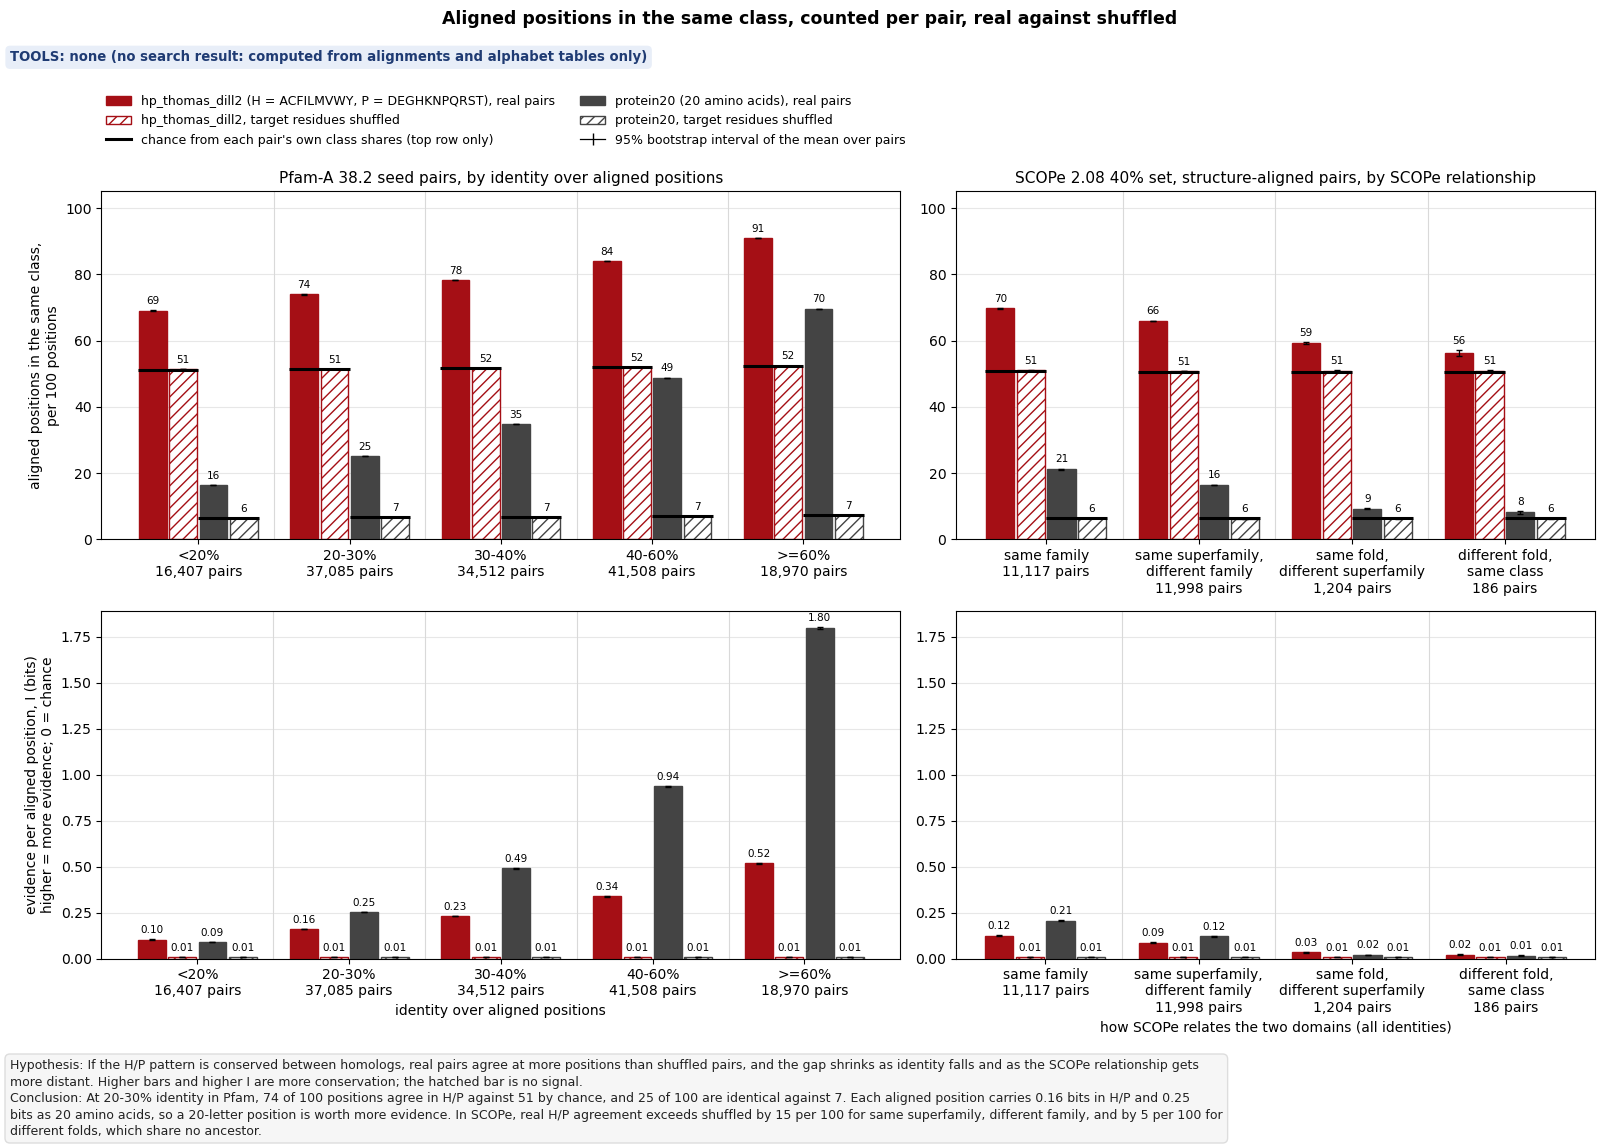

In [3]:
METRICS = ["agree", "agree_null", "expected", "evidence", "evidence_null"]


def summary(df, by):
    out = None
    for m in METRICS:
        s = hc.summarise(df, by + ["alphabet"], m)
        out = s if out is None else out.join(s.drop("n"), on=by + ["alphabet"])
    return out


pf_s = summary(pfam, ["identity_bin"]).with_columns(
    pl.col("identity_bin").cast(pl.Enum(hc.IDENTITY_LABELS))
)
sc_s = summary(scope, ["category"]).with_columns(
    pl.col("category").cast(pl.Enum(CAT_ORDER))
)


def per100_table(s, key):
    return (
        s.sort(key, "alphabet")
        .select(
            key,
            "alphabet",
            pl.col("n").alias("pairs"),
            *[
                pl.format(
                    "{} [{}-{}]",
                    (pl.col(f"{m}_mean") * 100).round(1),
                    (pl.col(f"{m}_lo") * 100).round(1),
                    (pl.col(f"{m}_hi") * 100).round(1),
                ).alias(lab)
                for m, lab in [
                    ("agree", "agree per 100"),
                    ("agree_null", "shuffled per 100"),
                    ("expected", "chance per 100"),
                ]
            ],
            *[
                pl.format(
                    "{} [{}-{}]",
                    pl.col(f"{m}_mean").round(3),
                    pl.col(f"{m}_lo").round(3),
                    pl.col(f"{m}_hi").round(3),
                ).alias(lab)
                for m, lab in [("evidence", "I bits"), ("evidence_null", "I shuffled bits")]
            ],
        )
    )


print("Pfam-A 38.2 seed pairs, mean [95% bootstrap interval]")
print(per100_table(pf_s, "identity_bin"))
print("\nSCOPe 2.08 40% set, USalign pairs, mean [95% bootstrap interval]")
print(per100_table(sc_s, "category"))

W = 0.2
SLOTS = [(HP, False, -1.5), (HP, True, -0.5), (P20, False, 0.5), (P20, True, 1.5)]


def draw(ax_top, ax_bot, s, key, order, ticklabels):
    x = np.arange(len(order))
    for a, shuffled, off in SLOTS:
        d = s.filter(pl.col("alphabet") == a).sort(key)
        m = "agree_null" if shuffled else "agree"
        e = "evidence_null" if shuffled else "evidence"
        xi = x + off * W
        style = (
            dict(facecolor="white", edgecolor=COLOR[a], hatch="///", lw=1.0)
            if shuffled
            else dict(facecolor=COLOR[a], edgecolor=COLOR[a], lw=1.0)
        )
        for ax, col, scale, fmt in [(ax_top, m, 100, "{:.0f}"), (ax_bot, e, 1, "{:.2f}")]:
            mean = d[f"{col}_mean"].to_numpy() * scale
            lo = d[f"{col}_lo"].to_numpy() * scale
            hi = d[f"{col}_hi"].to_numpy() * scale
            ax.bar(xi, mean, W * 0.92, **style)
            ax.errorbar(xi, mean, yerr=[mean - lo, hi - mean], fmt="none",
                        ecolor="black", lw=0.9, capsize=2)
            for xx, v, h in zip(xi, mean, hi):
                ax.annotate(fmt.format(v), (xx, h), xytext=(0, 3), textcoords="offset points",
                            ha="center", va="bottom", fontsize=7.5)
        if not shuffled:
            ch = d["expected_mean"].to_numpy() * 100
            ax_top.hlines(ch, xi - W * 0.5, xi + W * 1.5, color="black", lw=2.2, zorder=5)
    for ax in (ax_top, ax_bot):
        ax.set_xticks(x, ticklabels)
        ax.grid(axis="y", alpha=0.3)
        ax.set_axisbelow(True)
        for b in x[:-1] + 0.5:
            ax.axvline(b, color="0.85", lw=0.8)


# The legend gets its own grid row above the plots, so tight_layout cannot push it onto them.
fig = plt.figure(figsize=(16, 9.8))
gs = fig.add_gridspec(3, 2, height_ratios=[0.4, 4, 4], width_ratios=[5, 4])
leg_ax = fig.add_subplot(gs[0, :])
leg_ax.axis("off")
axes = np.empty((2, 2), dtype=object)
axes[0, 0] = fig.add_subplot(gs[1, 0])
axes[0, 1] = fig.add_subplot(gs[1, 1], sharey=axes[0, 0])
axes[1, 0] = fig.add_subplot(gs[2, 0])
axes[1, 1] = fig.add_subplot(gs[2, 1], sharey=axes[1, 0])
pf_n = pf_s.filter(pl.col("alphabet") == HP).sort("identity_bin")
sc_n = sc_s.filter(pl.col("alphabet") == HP).sort("category")
draw(axes[0, 0], axes[1, 0], pf_s, "identity_bin", hc.IDENTITY_LABELS,
     [f"{b}\n{n:,} pairs" for b, n in zip(pf_n["identity_bin"], pf_n["n"])])
draw(axes[0, 1], axes[1, 1], sc_s, "category", CAT_ORDER,
     [f"{CAT_LABEL[c]}\n{n:,} pairs" for c, n in zip(sc_n["category"], sc_n["n"])])
axes[0, 0].set_title("Pfam-A 38.2 seed pairs, by identity over aligned positions", fontsize=11)
axes[0, 1].set_title("SCOPe 2.08 40% set, structure-aligned pairs, by SCOPe relationship",
                     fontsize=11)
axes[0, 0].set_ylabel("aligned positions in the same class,\nper 100 positions")
axes[1, 0].set_ylabel("evidence per aligned position, I (bits)\nhigher = more evidence; 0 = chance")
axes[1, 0].set_xlabel("identity over aligned positions")
axes[1, 1].set_xlabel("how SCOPe relates the two domains (all identities)")
axes[0, 0].set_ylim(0, 105)

handles = [
    Patch(facecolor=COLOR[HP], edgecolor=COLOR[HP],
          label="hp_thomas_dill2 (H = ACFILMVWY, P = DEGHKNPQRST), real pairs"),
    Patch(facecolor="white", edgecolor=COLOR[HP], hatch="///",
          label="hp_thomas_dill2, target residues shuffled"),
    Line2D([], [], color="black", lw=2.2,
           label="chance from each pair's own class shares (top row only)"),
    Patch(facecolor=COLOR[P20], edgecolor=COLOR[P20], label="protein20 (20 amino acids), real pairs"),
    Patch(facecolor="white", edgecolor=COLOR[P20], hatch="///",
          label="protein20, target residues shuffled"),
    Line2D([], [], color="black", lw=0.9, marker="|", ms=8,
           label="95% bootstrap interval of the mean over pairs"),
]
leg_ax.legend(handles=handles, loc="lower left", ncol=2, fontsize=9, frameon=False,
              borderaxespad=0, bbox_to_anchor=(0, -0.9))


def val(s, key, k, a, m):
    return s.filter((pl.col(key) == k) & (pl.col("alphabet") == a))[f"{m}_mean"][0]


hp_a = 100 * val(pf_s, "identity_bin", "20-30%", HP, "agree")
hp_c = 100 * val(pf_s, "identity_bin", "20-30%", HP, "expected")
p_a = 100 * val(pf_s, "identity_bin", "20-30%", P20, "agree")
p_c = 100 * val(pf_s, "identity_bin", "20-30%", P20, "expected")
hp_i = val(pf_s, "identity_bin", "20-30%", HP, "evidence")
p_i = val(pf_s, "identity_bin", "20-30%", P20, "evidence")
df_hp = 100 * (val(sc_s, "category", "diff_fold_same_class", HP, "agree")
               - val(sc_s, "category", "diff_fold_same_class", HP, "agree_null"))
sf_hp = 100 * (val(sc_s, "category", "same_superfamily_diff_family", HP, "agree")
               - val(sc_s, "category", "same_superfamily_diff_family", HP, "agree_null"))
hc.finish_figure(
    fig,
    FIG / "273_hp_vs_protein20_agreement_per_100_and_bits_pfam_seed_scope40.png",
    tools=hc.NO_TOOL,
    title="Aligned positions in the same class, counted per pair, real against shuffled",
    hypothesis=(
        "If the H/P pattern is conserved between homologs, real pairs agree at more positions "
        "than shuffled pairs, and the gap shrinks as identity falls and as the SCOPe relationship "
        "gets more distant. "
        "Higher bars and higher I are more conservation; the hatched bar is no signal."
    ),
    conclusion=(
        f"At 20-30% identity in Pfam, {hp_a:.0f} of 100 positions agree in H/P against "
        f"{hp_c:.0f} by chance, and {p_a:.0f} of 100 are identical against {p_c:.0f}. Each "
        f"aligned position carries {hp_i:.2f} bits in H/P and {p_i:.2f} bits as 20 amino acids, "
        f"so a 20-letter position is worth more evidence. In SCOPe, real H/P agreement exceeds "
        f"shuffled by {sf_hp:.0f} per 100 for same superfamily, different family, and by "
        f"{df_hp:.0f} per 100 for different folds, which share no ancestor."
    ),
)

## 3. Measured against the kappa-based estimates

The estimates were made from kappa with Swiss-Prot residue shares, at 20-30% identity. The
measured values are the Pfam 20-30% bin from section 2, and for comparison the SCOPe pairs
in the same superfamily but a different family, also at 20-30% identity.

For I there are two measured versions. "Mean of per-pair I" averages the per-pair values,
which is what section 2 plots. "I of the mean rates" puts the bin's mean Pr(agree) and mean
Pr(chance) into the formula once, which is how the estimate was made. They differ because I
curves upward: pairs far above chance add more than pairs near chance take away, and short
alignments add some I by sampling noise alone (the shuffled I).

Each quantity is drawn on the axis of its unit: per 100 positions on the left, bits on the
right. Black horizontal bars are the estimates. A measured point within the grey band
(estimate ± 3 per 100, or ± 0.03 bits) passes the decision rule.

shape: (20, 11)
┌──────────────┬─────────┬─────────────────────────────────┬─────────────────────────────────┬──────────┬──────────┬───────┬───────┬────────────┬─────────────┬───────┐
│ quantity     ┆ unit    ┆ dataset                         ┆ version                         ┆ estimate ┆ measured ┆ lo    ┆ hi    ┆ difference ┆ within_rule ┆ pairs │
│ ---          ┆ ---     ┆ ---                             ┆ ---                             ┆ ---      ┆ ---      ┆ ---   ┆ ---   ┆ ---        ┆ ---         ┆ ---   │
│ str          ┆ str     ┆ str                             ┆ str                             ┆ f64      ┆ f64      ┆ f64   ┆ f64   ┆ f64        ┆ bool        ┆ i64   │
╞══════════════╪═════════╪═════════════════════════════════╪═════════════════════════════════╪══════════╪══════════╪═══════╪═══════╪════════════╪═════════════╪═══════╡
│ H/P agree    ┆ per 100 ┆ Pfam 20-30%                     ┆ measured mean                   ┆ 74.0     ┆ 73.9     ┆ 73.8  ┆ 73.9  ┆ -0.1       

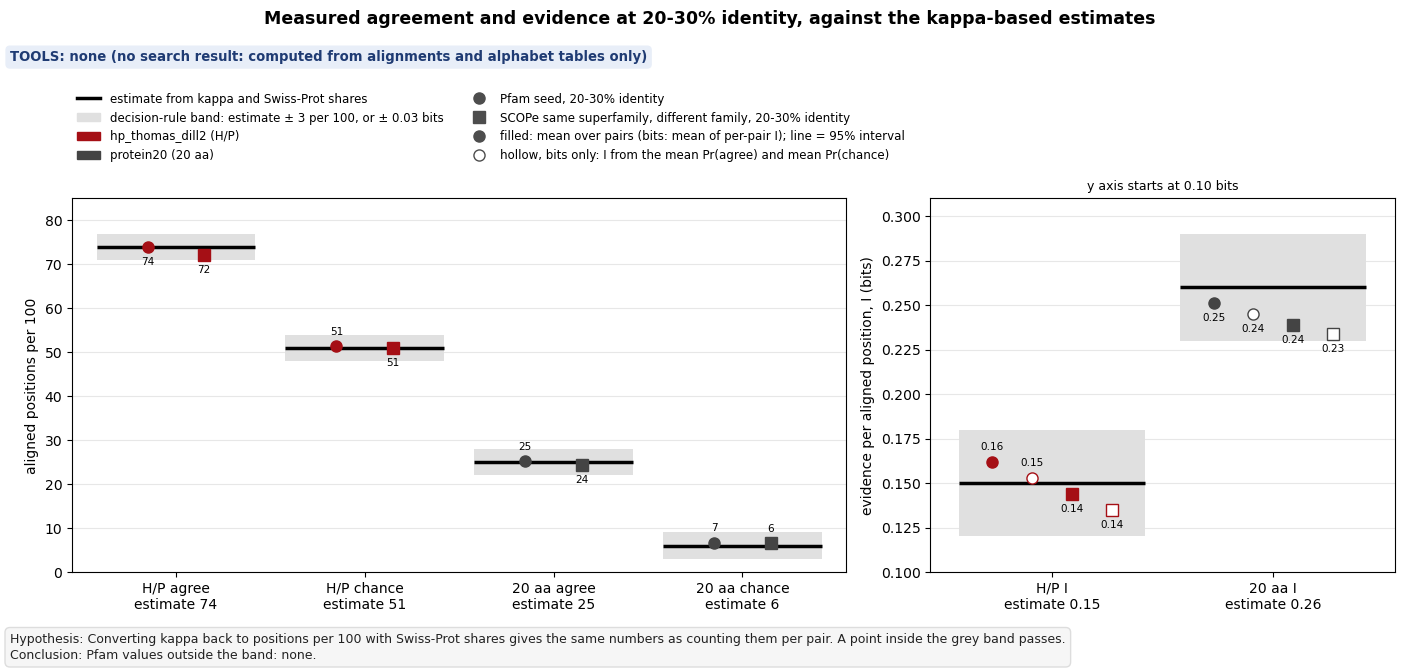

In [4]:
EST = [
    ("H/P agree", HP, "agree", 74),
    ("H/P chance", HP, "expected", 51),
    ("20 aa agree", P20, "agree", 25),
    ("20 aa chance", P20, "expected", 6),
]
EST_I = [("H/P I", HP, 0.15), ("20 aa I", P20, 0.26)]
TOL_100, TOL_BITS = 3, 0.03

sc_bin = summary(
    scope.filter(
        (pl.col("category") == "same_superfamily_diff_family")
        & (pl.col("identity_bin") == "20-30%")
    ),
    [],
)
pf_bin = pf_s.filter(pl.col("identity_bin") == "20-30%")


def g(s, a, m, part="mean"):
    return s.filter(pl.col("alphabet") == a)[f"{m}_{part}"][0]


rows = []
for lab, a, m, est in EST:
    for ds, s in [("Pfam 20-30%", pf_bin), ("SCOPe same superfamily, diff. family, 20-30%", sc_bin)]:
        v = 100 * g(s, a, m)
        rows.append(dict(quantity=lab, unit="per 100", dataset=ds, version="measured mean",
                         estimate=est, measured=round(v, 1),
                         lo=round(100 * g(s, a, m, "lo"), 1), hi=round(100 * g(s, a, m, "hi"), 1),
                         difference=round(v - est, 1), within_rule=abs(v - est) <= TOL_100,
                         pairs=s.filter(pl.col("alphabet") == a)["n"][0]))
for lab, a, est in EST_I:
    for ds, s in [("Pfam 20-30%", pf_bin), ("SCOPe same superfamily, diff. family, 20-30%", sc_bin)]:
        n = s.filter(pl.col("alphabet") == a)["n"][0]
        for version, v, lo, hi in [
            ("mean of per-pair I", g(s, a, "evidence"), g(s, a, "evidence", "lo"), g(s, a, "evidence", "hi")),
            ("mean of per-pair I minus shuffled I", g(s, a, "evidence") - g(s, a, "evidence_null"), None, None),
            ("I of the mean rates", hc.bernoulli_kl_bits(g(s, a, "agree"), g(s, a, "expected")), None, None),
        ]:
            rows.append(dict(quantity=lab, unit="bits", dataset=ds, version=version, estimate=est,
                             measured=round(float(v), 3),
                             lo=None if lo is None else round(lo, 3),
                             hi=None if hi is None else round(hi, 3),
                             difference=round(float(v) - est, 3),
                             within_rule=abs(float(v) - est) <= TOL_BITS, pairs=n))
cmp = pl.DataFrame(rows)
print(cmp)

# Chance for protein20 from the pooled residue shares of all 20-30% pairs, for comparison
# with the per-pair chance above. If they differ, partners' compositions are correlated.
aln_bin = hc.add_identity_bin(
    pl.read_parquet(PFAM_ALN).filter(pl.col("lali") >= MIN_COLS)
).filter(pl.col("identity_bin") == "20-30%")
codes = hc.TABLES[P20][
    np.frombuffer("".join(aln_bin["qaln"].to_list() + aln_bin["taln"].to_list()).encode(), np.uint8)
]
codes = codes[codes != hc.GAP]
f_pool = np.bincount(codes, minlength=20) / codes.size
print(
    f"\nprotein20 chance per 100 at 20-30% identity: from pooled residue shares "
    f"{100 * (f_pool ** 2).sum():.2f}; mean of per-pair chance {100 * g(pf_bin, P20, 'expected'):.2f}"
)

# x offset of each point inside its group; the I-minus-shuffled version is in the table only.
OFFSET = {
    ("Pfam 20-30%", "measured mean"): -0.15,
    ("SCOPe same superfamily, diff. family, 20-30%", "measured mean"): 0.15,
    ("Pfam 20-30%", "mean of per-pair I"): -0.27,
    ("Pfam 20-30%", "I of the mean rates"): -0.09,
    ("SCOPe same superfamily, diff. family, 20-30%", "mean of per-pair I"): 0.09,
    ("SCOPe same superfamily, diff. family, 20-30%", "I of the mean rates"): 0.27,
}
DS_MARK = {"Pfam 20-30%": "o", "SCOPe same superfamily, diff. family, 20-30%": "s"}
fig = plt.figure(figsize=(14, 5.6))
gs = fig.add_gridspec(2, 2, height_ratios=[0.55, 4], width_ratios=[4, 2.4])
leg_ax = fig.add_subplot(gs[0, :])
leg_ax.axis("off")
axl, axr = fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])
for ax, unit, labels, tol in [
    (axl, "per 100", [e[0] for e in EST], TOL_100),
    (axr, "bits", [e[0] for e in EST_I], TOL_BITS),
]:
    sub = cmp.filter(pl.col("unit") == unit)
    for i, lab in enumerate(labels):
        r0 = sub.filter(pl.col("quantity") == lab)
        est = r0["estimate"][0]
        a = HP if lab.startswith("H/P") else P20
        ax.fill_between([i - 0.42, i + 0.42], est - tol, est + tol, color="0.88", lw=0)
        ax.hlines(est, i - 0.42, i + 0.42, color="black", lw=2.5)
        for r in r0.iter_rows(named=True):
            key = (r["dataset"], r["version"])
            if key not in OFFSET:
                continue
            xx = i + OFFSET[key]
            hollow = r["version"] == "I of the mean rates"
            ax.plot(xx, r["measured"], DS_MARK[r["dataset"]], ms=8, mec=COLOR[a],
                    mfc="white" if hollow else COLOR[a], zorder=4)
            if r["lo"] is not None:
                ax.vlines(xx, r["lo"], r["hi"], color=COLOR[a], lw=1)
            ax.annotate(f"{r['measured']:.2f}" if unit == "bits" else f"{r['measured']:.0f}",
                        (xx, r["measured"]), textcoords="offset points",
                        # label on the side away from the estimate line, so it never sits on it
                        xytext=(0, 7) if r["measured"] >= est else (0, -7),
                        ha="center", va="bottom" if r["measured"] >= est else "top",
                        fontsize=7.5)
    ests = [sub.filter(pl.col("quantity") == lab)["estimate"][0] for lab in labels]
    ax.set_xticks(range(len(labels)), [f"{lab}\nestimate {e:g}" for lab, e in zip(labels, ests)])
    ax.set_xlim(-0.55, len(labels) - 0.45)
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)
axl.set_ylabel("aligned positions per 100")
axl.set_ylim(0, 85)
axr.set_ylabel("evidence per aligned position, I (bits)")
axr.set_ylim(0.10, 0.31)
axr.set_title("y axis starts at 0.10 bits", fontsize=9)
handles = [
    Line2D([], [], color="black", lw=2.5, label="estimate from kappa and Swiss-Prot shares"),
    Patch(color="0.88", label="decision-rule band: estimate ± 3 per 100, or ± 0.03 bits"),
    Patch(color=COLOR[HP], label="hp_thomas_dill2 (H/P)"),
    Patch(color=COLOR[P20], label="protein20 (20 aa)"),
    Line2D([], [], ls="none", marker="o", color="0.3", ms=8, label="Pfam seed, 20-30% identity"),
    Line2D([], [], ls="none", marker="s", color="0.3", ms=8,
           label="SCOPe same superfamily, different family, 20-30% identity"),
    Line2D([], [], ls="none", marker="o", mfc="0.3", mec="0.3", ms=8,
           label="filled: mean over pairs (bits: mean of per-pair I); line = 95% interval"),
    Line2D([], [], ls="none", marker="o", mfc="white", mec="0.3", ms=8,
           label="hollow, bits only: I from the mean Pr(agree) and mean Pr(chance)"),
]
leg_ax.legend(handles=handles, loc="lower left", ncol=2, fontsize=8.5, frameon=False,
              borderaxespad=0, bbox_to_anchor=(0, -0.45))

fails = cmp.filter(~pl.col("within_rule") & pl.col("dataset").str.starts_with("Pfam")
                   & pl.col("version").is_in(["measured mean", "mean of per-pair I"]))
fail_txt = "; ".join(
    f"{r['quantity']} {r['measured']} vs {r['estimate']}" for r in fails.iter_rows(named=True)
) or "none"
hc.finish_figure(
    fig,
    FIG / "273_measured_vs_kappa_estimates_pfam_seed_scope40_20_30pct.png",
    tools=hc.NO_TOOL,
    title="Measured agreement and evidence at 20-30% identity, against the kappa-based estimates",
    hypothesis=(
        "Converting kappa back to positions per 100 with Swiss-Prot shares gives the same "
        "numbers as counting them per pair. A point inside the grey band passes."
    ),
    conclusion=f"Pfam values outside the band: {fail_txt}.",
)

## 4. Summary and conclusions

**Question.** Do the kappa-based numbers for H/P agreement (74 vs 51 per 100 at 20-30%
identity; 25 vs 6 for 20 amino acids; I about 0.15 vs 0.26 bits) hold when agreement is
counted per pair and chance is measured by shuffling?

**Answer.** Yes, all six estimates fall within the decision-rule band. They can be quoted, with
this notebook as the source.

1. At 20-30% identity in Pfam seed pairs (37,085 pairs), 73.9 of 100 aligned positions share an
   H/P class (95% interval 73.8-73.9); the estimate was 74. Shuffling the target gives 51.4,
   the same as chance from the pairs' own class shares (51.4); the estimate was 51.
2. For the 20 amino acids at the same identity, 25.2 of 100 aligned positions are identical
   (estimate 25). Chance is 6.7 per 100, not 6. The pooled residue shares of the same pairs give
   6.0, the Swiss-Prot value, so the extra 0.7 comes from the two partners in a pair having more
   alike compositions than two random sequences. The shuffled value, 6.6, agrees with the
   per-pair formula.
3. Evidence per aligned position at 20-30% identity: H/P 0.162 bits, 20 amino acids 0.251 bits
   (estimates 0.15 and 0.26). Shuffled pairs score 0.006 bits in both alphabets, so the floor from
   finite alignments is small. Put through the formula once at the bin's mean rates, as the
   estimate was made, the values are 0.153 and 0.245. The H/P estimate is closer to that version;
   the 20-letter estimate is 0.009-0.015 bits high because it used chance 6 instead of 6.7.
4. In the SCOPe pairs from the same superfamily but a different family at 20-30% identity (2,118
   pairs), H/P agreement is 72.1 per 100 and I is 0.144 bits (20 amino acids: 24.4, 0.239 bits).
   The estimates hold there too.
5. One per-pair figure the kappa summary did not show: below 20% identity, H/P carries more
   evidence per aligned position than the 20 amino acids (Pfam 0.103 vs 0.091 bits; SCOPe same
   fold, different superfamily 0.033 vs 0.020). At 20% identity and above, 20 amino acids carry
   more, by 1.5x at 20-30% and 3.5x at 60% and above. Part of the H/P lead at low identity is
   packing, not ancestry: different-fold SCOPe pairs, which share no ancestor, still agree on
   56.2 H/P positions per 100 against 50.8 shuffled (186 pairs).

**Limits.** These are aligned positions only. The numbers say nothing about whether an
alignment can be found; for that see notebook 230 sections 4-6 (exact runs). The SCOPe
categories pool all identities, so the right column of section 2 mixes relatedness with
identity. Pfam seed pairs are capped at 6 per family, so a large family counts no more than
a small one with 4 or more seed members.

**Decision.** Keep quoting 74 vs 51 (H/P) and 25 vs 6.7 (20 amino acids, chance corrected from 6)
at 20-30% identity, and 0.16 vs 0.25 bits per aligned position, citing this notebook.